# Fine-Tuning a Pretrained LLM for Code Generation
### Using Qwen2.5-Coder-1.5B-Instruct + QLoRA

---

## Step 1 - Task Identification
**Task:** Code Generation  
Given a natural language instruction (e.g. *"Write a Python function to reverse a string"*), the model should generate correct, working code.

This is a **Supervised Fine-Tuning (SFT)** task using instruction–response pairs.

---

## Step 2 - Domain
**Domain:** Programming / Coding  
**Dataset:** `sahil2801/CodeAlpaca-20k` - 20,000 Python instruction-code pairs from HuggingFace Hub.

---

## Step 3 - Model Selection
**Model:** `Qwen/Qwen2.5-Coder-1.5B-Instruct`

| Property | Value |
|---|---|
| Released | November 2024 |
| Parameters | 1.5B |
| Training data | 5.5 trillion tokens of code + text |
| Context window | 128K tokens |
| Fine-tuning method | QLoRA (4-bit quantized LoRA) |

---

## Step 4 - Setup & Configuration

In [1]:
# Install required libraries (pinned for notebook compatibility)
%pip install -q "transformers==4.46.3" "trl==0.11.4" "datasets==2.21.0" "accelerate==1.0.1" \
               "evaluate==0.4.3" "sacrebleu==2.4.3" "peft==0.13.2" "bitsandbytes==0.45.0" "torch>=2.2" \
               "scikit-learn>=1.4" "matplotlib>=3.8"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
    PeftModel,
 )
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
import evaluate
import numpy as np

# ── Check GPU ────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device : {device}")
if device == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM         : {vram_gb:.1f} GB")
    if vram_gb < 6:
        print("⚠️  Low VRAM detected — reduce BATCH_SIZE to 1 and MAX_LENGTH to 128")

Using device : cuda
GPU          : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM         : 6.4 GB


In [ ]:
# ─────────────────────────────────────────────────────
#  CONFIGURATION  (edit these as needed)
# ─────────────────────────────────────────────────────

# Model & Data
MODEL_NAME    = "Qwen/Qwen2.5-Coder-1.5B-Instruct"   
DATASET_NAME  = "sahil2801/CodeAlpaca-20k"             # Instruction-code pairs
OUTPUT_DIR    = "./qwen-coder-finetuned"               # Save location

# Control training reruns
RUN_FINE_TUNING = False   # Set to True only when you intentionally want to retrain

# QLoRA settings (keeps VRAM usage low)
USE_4BIT      = (device == "cuda")  # Enable only when CUDA is available
LORA_R        = 16       # LoRA rank (higher = more trainable params)
LORA_ALPHA    = 32       # LoRA scaling factor
LORA_DROPOUT  = 0.05
LORA_TARGET   = ["q_proj", "k_proj", "v_proj", "o_proj",
                 "gate_proj", "up_proj", "down_proj"]  # Attention + MLP layers

# Training
MAX_LENGTH    = 512      # Reduce to 256 if OOM
NUM_EPOCHS    = 3
BATCH_SIZE    = 4        # Reduce to 2 if OOM
GRAD_ACCUM    = 4        # Effective batch = BATCH_SIZE * GRAD_ACCUM = 16
LEARNING_RATE = 2e-4     # Slightly higher LR works well for LoRA
WARMUP_RATIO  = 0.03
TRAIN_SPLIT   = 0.9
SAVE_STEPS    = 500
EVAL_STEPS    = 500
LOGGING_STEPS = 50

# Evaluation
NUM_EVAL_SAMPLES = 100

if device == "cpu":
    # Safer defaults for CPU-only systems
    BATCH_SIZE = 1
    GRAD_ACCUM = 1
    MAX_LENGTH = 256
    NUM_EVAL_SAMPLES = 20

print("Configuration set.")
print(f"RUN_FINE_TUNING : {RUN_FINE_TUNING}")
print(f"USE_4BIT        : {USE_4BIT}")

Configuration set.
RUN_FINE_TUNING : False
USE_4BIT        : True


### 4a - Load Tokenizer

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Qwen2.5 uses <|endoftext|> as eos; set pad = eos to avoid warnings
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # Required for SFT with causal LMs

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size      : {tokenizer.vocab_size}")

Tokenizer loaded: Qwen/Qwen2.5-Coder-1.5B-Instruct
Vocab size      : 151643


### 4b - Load Model with QLoRA (4-bit quantization)

In [5]:
# QLoRA config — loads model in 4-bit to save VRAM
if USE_4BIT and device == "cuda":
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,   # Nested quantization
        bnb_4bit_quant_type="nf4",        # Normal float 4-bit
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    print("QLoRA: loading model in 4-bit (NF4)")
else:
    bnb_config = None
    print("Loading model in full precision (no quantization)")

try:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",                   # Auto-assigns to GPU/CPU
        trust_remote_code=True,
        torch_dtype=torch.bfloat16 if (device == "cuda" and not USE_4BIT) else None,
    )
except Exception as e:
    # Fallback path if quantized loading fails on current platform/driver
    print(f"Quantized load failed, retrying without quantization: {e}")
    USE_4BIT = False
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.float16 if device == "cuda" else None,
    )

model.config.use_cache = False           # Required for gradient checkpointing

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"\nModel loaded : {MODEL_NAME}")
print(f"Parameters   : {total_params:.1f}M")
print(f"4-bit active : {USE_4BIT}")

QLoRA: loading model in 4-bit (NF4)

Model loaded : Qwen/Qwen2.5-Coder-1.5B-Instruct
Parameters   : 888.6M
4-bit active : True


### 4c - Apply LoRA Adapters

In [6]:
# Prepare quantized model for k-bit training before injecting LoRA adapters
if USE_4BIT:
    model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET,
    bias="none",
)

model = get_peft_model(model, lora_config)

# Show how many parameters are actually being trained
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable/1e6:.2f}M  ({100*trainable/total:.2f}% of total)")
print(f"Frozen params    : {(total-trainable)/1e6:.2f}M")
print("(LoRA only trains a small fraction — this is intentional and efficient)")

Trainable params : 18.46M  (2.04% of total)
Frozen params    : 888.62M
(LoRA only trains a small fraction — this is intentional and efficient)


### 4d - Load & Format Dataset

In [7]:
raw_dataset = load_dataset(DATASET_NAME)
print(raw_dataset)
print("\nSample entry:")
print(raw_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 20022
    })
})

Sample entry:
{'output': 'arr = [2, 4, 6, 8, 10]', 'instruction': 'Create an array of length 5 which contains all even numbers between 1 and 10.', 'input': ''}


In [8]:
def format_sample(example):
    """
    Format using Qwen2.5's native ChatML template:
        <|im_start|>system\n...<|im_end|>
        <|im_start|>user\n...<|im_end|>
        <|im_start|>assistant\n...<|im_end|>
    """
    instruction = example.get("instruction", "").strip()
    input_ctx   = example.get("input", "").strip()
    output      = example.get("output", "").strip()

    user_content = instruction
    if input_ctx:
        user_content += f"\n\nInput:\n{input_ctx}"

    messages = [
        {"role": "system",    "content": "You are an expert Python programmer. Write clear, correct, and well-commented code."},
        {"role": "user",      "content": user_content},
        {"role": "assistant", "content": output},
    ]

    # Apply Qwen's native chat template
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}


formatted = raw_dataset["train"].map(format_sample, remove_columns=raw_dataset["train"].column_names)
split     = formatted.train_test_split(test_size=1 - TRAIN_SPLIT, seed=42)

train_dataset = split["train"]
eval_dataset  = split["test"]

print(f"Train samples : {len(train_dataset)}")
print(f"Eval  samples : {len(eval_dataset)}")
print("\nFormatted sample (truncated):")
print(train_dataset[0]["text"][:400])

Train samples : 18019
Eval  samples : 2003

Formatted sample (truncated):
<|im_start|>system
You are an expert Python programmer. Write clear, correct, and well-commented code.<|im_end|>
<|im_start|>user
Create a Java class which sorts the given array of numbers.

Input:
[9, 2, 4, 3, 6, 1]<|im_end|>
<|im_start|>assistant
class ArraySort { 
  
    void sort(int arr[]) { 
        int n = arr.length; 
  
        // One by one move boundary of unsorted subarray 
        for


### 4e - Training Configuration (SFTTrainer)

In [9]:
use_bf16 = (device == "cuda" and torch.cuda.is_bf16_supported())
use_fp16 = (device == "cuda" and not use_bf16)

# Eval uses smaller batches to avoid OOM on 6 GB GPUs
EVAL_BATCH_SIZE = 1 if device == "cuda" else BATCH_SIZE

sft_config = SFTConfig(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = EVAL_BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    gradient_checkpointing      = True,      # Saves VRAM at cost of ~20% speed
    learning_rate               = LEARNING_RATE,
    warmup_ratio                = WARMUP_RATIO,
    lr_scheduler_type           = "cosine",  # Cosine decay works well for LLMs
    bf16                        = use_bf16,
    fp16                        = use_fp16,
    logging_steps               = LOGGING_STEPS,
    eval_strategy               = "steps",
    eval_steps                  = EVAL_STEPS,
    save_steps                  = SAVE_STEPS,
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    report_to                   = "none",
    max_seq_length              = MAX_LENGTH,
    dataset_text_field          = "text",    # Column name from format_sample()
    packing                     = False,     # Set True to pack short sequences (faster)
)

trainer = SFTTrainer(
    model         = model,
    args          = sft_config,
    train_dataset = train_dataset,
    eval_dataset  = eval_dataset,
    tokenizer     = tokenizer,
)

print("SFTTrainer ready.")
print(f"bf16={use_bf16}, fp16={use_fp16}, eval_batch={EVAL_BATCH_SIZE}")

d:\codes\CCS-249_25-26_Activities\.venv\Lib\site-packages\trl\trainer\sft_trainer.py:401: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  super().__init__(


SFTTrainer ready.
bf16=True, fp16=False, eval_batch=1


### Start Fine-Tuning

In [10]:
import os
import shutil
import subprocess
from transformers import TrainerCallback

MONITOR_EVERY_STEPS = 5  # Print GPU stats every N optimizer steps during training

def _query_nvidia_smi():
    if shutil.which("nvidia-smi") is None:
        return None
    try:
        cmd = [
            "nvidia-smi",
            "--query-gpu=utilization.gpu,memory.used,memory.total",
            "--format=csv,noheader,nounits",
        ]
        row = subprocess.check_output(cmd, text=True).strip().splitlines()[0]
        util, mem_used, mem_total = [x.strip() for x in row.split(",")]
        return util, mem_used, mem_total
    except Exception:
        return None

def _gpu_snapshot(tag: str):
    if not torch.cuda.is_available():
        print(f"[{tag}] CUDA not available (running on CPU)")
        return

    try:
        torch.cuda.synchronize()
    except Exception as e:
        print(f"[{tag}] CUDA synchronize skipped: {e}")

    alloc = torch.cuda.memory_allocated() / (1024 ** 3)
    reserved = torch.cuda.memory_reserved() / (1024 ** 3)
    peak = torch.cuda.max_memory_allocated() / (1024 ** 3)
    print(f"[{tag}] torch.cuda | allocated={alloc:.2f} GB, reserved={reserved:.2f} GB, peak={peak:.2f} GB")

    smi = _query_nvidia_smi()
    if smi is not None:
        util, mem_used, mem_total = smi
        print(f"[{tag}] nvidia-smi | util={util}%, mem={mem_used}/{mem_total} MiB")

class GPUStepMonitorCallback(TrainerCallback):
    def on_step_end(self, args, state, control, **kwargs):
        if not torch.cuda.is_available():
            return
        if state.global_step > 0 and state.global_step % MONITOR_EVERY_STEPS == 0:
            _gpu_snapshot(f"Step {state.global_step}")

if RUN_FINE_TUNING:
    # Avoid duplicate callback registration if you rerun this cell
    if not any(cb.__class__.__name__ == "GPUStepMonitorCallback" for cb in trainer.callback_handler.callbacks):
        trainer.add_callback(GPUStepMonitorCallback())

    print("Starting fine-tuning...")
    _gpu_snapshot("Before train")
    trainer.train()
    _gpu_snapshot("After train")
    print("Fine-tuning complete!")

    # Save LoRA adapter weights (NOT the full model — much smaller file)
    model.save_pretrained(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)
    print(f"LoRA adapter saved to: {OUTPUT_DIR}")
else:
    print("RUN_FINE_TUNING is False -> skipping retraining.")
    adapter_cfg = os.path.join(OUTPUT_DIR, "adapter_config.json")
    if os.path.exists(adapter_cfg):
        # Load existing trained adapter so evaluation cells can run without retraining
        try:
            base_model = model.get_base_model() if hasattr(model, "get_base_model") else model
            model = PeftModel.from_pretrained(base_model, OUTPUT_DIR, is_trainable=False)
            trainer.model = model
            print(f"Loaded trained LoRA adapter from: {OUTPUT_DIR}")
        except Exception as e:
            print(f"Could not load saved adapter automatically: {e}")
            print("Proceeding with current in-memory model.")
    else:
        print(f"No saved adapter found at: {OUTPUT_DIR}")
        print("Set RUN_FINE_TUNING=True if you want to train and create adapter files.")

RUN_FINE_TUNING is False -> skipping retraining.
Loaded trained LoRA adapter from: ./qwen-coder-finetuned


---

## Step 5 - Evaluation

We use three evaluation methods:
1. **Perplexity** - how confidently the model predicts held-out code (lower = better)
2. **BLEU Score** - n-gram overlap between generated and reference code
3. **Qualitative** - manual inspection of sample outputs

In [11]:
# ── 5a: Perplexity (standalone, robust fallback) ───────
import math
import os

# Keep this modest for stable evaluation on limited VRAM/RAM
EVAL_MAX_SAMPLES = min(50, len(eval_dataset))
eval_texts = eval_dataset.select(range(EVAL_MAX_SAMPLES))["text"]

def compute_perplexity_from_texts(eval_model, tokenizer, texts, run_device="cuda", batch_size=1):
    eval_model.eval()
    losses = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            encoded = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
            )
            encoded["labels"] = encoded["input_ids"].clone()
            encoded = {k: v.to(run_device) for k, v in encoded.items()}

            outputs = eval_model(**encoded)
            losses.append(float(outputs.loss.detach().cpu()))

    mean_loss = float(np.mean(losses))
    ppl = float(math.exp(mean_loss))
    return mean_loss, ppl

def load_fresh_cpu_eval_model():
    print("Loading a fresh CPU model for fallback evaluation...")
    cpu_base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        trust_remote_code=True,
        device_map=None,
        torch_dtype=torch.float32,
    )
    adapter_cfg = os.path.join(OUTPUT_DIR, "adapter_config.json")
    if os.path.exists(adapter_cfg):
        cpu_model = PeftModel.from_pretrained(
            cpu_base, OUTPUT_DIR, is_trainable=False, torch_device="cpu"
        )
        print(f"Loaded LoRA adapter from: {OUTPUT_DIR}")
        return cpu_model
    print("No adapter found; using base model for fallback evaluation.")
    return cpu_base

try:
    # Primary path: evaluate with current in-memory model on configured device
    eval_loss, perplexity = compute_perplexity_from_texts(
        model, tokenizer, eval_texts, run_device=device, batch_size=1
    )
    eval_device = device
except Exception as e:
    print(f"Primary evaluation failed ({e}). Switching to fresh CPU fallback...")
    cpu_eval_model = load_fresh_cpu_eval_model()
    eval_loss, perplexity = compute_perplexity_from_texts(
        cpu_eval_model, tokenizer, eval_texts, run_device="cpu", batch_size=1
    )
    eval_device = "cpu"

print(f"Eval Device : {eval_device}")
print(f"Eval Samples: {EVAL_MAX_SAMPLES}")
print(f"Eval Loss   : {eval_loss:.4f}")
print(f"Perplexity  : {perplexity:.2f}")
print("(Lower perplexity = better code language model)")

Eval Device : cuda
Eval Samples: 50
Eval Loss   : 0.8534
Perplexity  : 2.35
(Lower perplexity = better code language model)


In [12]:
# ── 5b: Example generation (safe device handling) ───────
bleu = evaluate.load("sacrebleu")

# Prefer already-loaded CPU fallback model when available
gen_model = cpu_eval_model if "cpu_eval_model" in globals() else model
gen_device = next(gen_model.parameters()).device.type

test_prompts = [
    "Write a Python function to check if a number is prime.",
    "Create a function that reverses a linked list.",
    "Implement quicksort in Python.",
    "Write a function to compute Fibonacci using recursion.",
    "Create a class for a bank account with deposit and withdraw methods.",
]

def run_generation_batch(active_model, active_device):
    outputs = []
    for i, user_content in enumerate(test_prompts, 1):
        messages = [
            {"role": "system", "content": "You are a helpful coding assistant."},
            {"role": "user", "content": user_content},
        ]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH // 2,
        ).to(active_device)

        with torch.no_grad():
            output_ids = active_model.generate(
                **inputs,
                max_new_tokens=160,
                do_sample=True,
                temperature=0.2,
                top_p=0.9,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        response = decoded[len(prompt):].strip() if decoded.startswith(prompt) else decoded
        outputs.append((i, user_content, response))
    return outputs

try:
    predictions = run_generation_batch(gen_model, gen_device)
except Exception as e:
    print(f"Primary generation path failed ({e}). Falling back to fresh CPU model...")
    gen_model = load_fresh_cpu_eval_model() if "load_fresh_cpu_eval_model" in globals() else model
    gen_device = "cpu"
    predictions = run_generation_batch(gen_model, gen_device)

for i, prompt_text, response in predictions:
    print(f"\nExample {i}")
    print(f"Prompt: {prompt_text}")
    print(f"Generated:\n{response}\n")
    print("-" * 70)


Example 1
Prompt: Write a Python function to check if a number is prime.
Generated:
system
You are a helpful coding assistant.
user
Write a Python function to check if a number is prime.
assistant
def is_prime(n):
    """Check if a given number is prime."""
    # Check for 0 and 1
    if n <= 1:
        return False

    # Check for factors
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False

    # If no factors found, it's a prime
    return True

if __name__ == '__main__':
    print(is_prime(7)) # Output: True
    print(is_prime(8)) # Output: False
    print(is_prime(9)) # Output: False
    print(is_prime(11)) # Output: True
    print(is_prime(13)) # Output: True


----------------------------------------------------------------------

Example 2
Prompt: Create a function that reverses a linked list.
Generated:
system
You are a helpful coding assistant.
user
Create a function that reverses a linked list.
assistant
def reverse(head):
    prev = None

In [13]:
# ── 5c: BLEU score (safe device handling) ───────────────
print("=" * 65)
print("       QUALITATIVE EVALUATION — Sample Outputs")
print("=" * 65)

# Reuse predictions from Step 5b if available
if "predictions" not in globals() or len(predictions) == 0:
    print("No predictions found from Step 5b. Running quick generation now...")
    gen_model = cpu_eval_model if "cpu_eval_model" in globals() else model
    gen_device = next(gen_model.parameters()).device.type

    quick_prompts = [
        "Write a Python function to check if a number is prime.",
        "Implement quicksort in Python.",
        "Write a function to compute Fibonacci using recursion.",
    ]
    predictions = []
    for i, user_content in enumerate(quick_prompts, 1):
        messages = [
            {"role": "system", "content": "You are a helpful coding assistant."},
            {"role": "user", "content": user_content},
        ]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256).to(gen_device)
        with torch.no_grad():
            output_ids = gen_model.generate(
                **inputs,
                max_new_tokens=120,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        response = decoded[len(prompt):].strip() if decoded.startswith(prompt) else decoded
        predictions.append((i, user_content, response))

references = [
    "def is_prime(n):\n if n < 2: return False\n for i in range(2, int(n**0.5)+1):\n  if n % i == 0: return False\n return True",
    "class Node:\n def __init__(self, val):\n  self.val=val; self.next=None\ndef reverse(head):\n prev=None\n while head:\n  nxt=head.next\n  head.next=prev\n  prev=head\n  head=nxt\n return prev",
    "def quicksort(arr):\n if len(arr)<=1: return arr\n pivot=arr[len(arr)//2]\n left=[x for x in arr if x<pivot]\n mid=[x for x in arr if x==pivot]\n right=[x for x in arr if x>pivot]\n return quicksort(left)+mid+quicksort(right)",
    "def fib(n):\n if n<=1: return n\n return fib(n-1)+fib(n-2)",
    "class BankAccount:\n def __init__(self,b=0): self.balance=b\n def deposit(self,a): self.balance += a\n def withdraw(self,a):\n  if a<=self.balance: self.balance -= a",
]

pred_texts = [x[2] for x in predictions]
trimmed_refs = references[:len(pred_texts)]
bleu_result = bleu.compute(predictions=pred_texts, references=[[r] for r in trimmed_refs])

print(f"\nBLEU Score: {bleu_result['score']:.2f}")
print("(Higher BLEU = closer to reference solutions)")

       QUALITATIVE EVALUATION — Sample Outputs

BLEU Score: 16.07
(Higher BLEU = closer to reference solutions)


In [14]:
# ── 5d: Final summary table ─────────────────────────────
print("\n" + "=" * 45)
print("         EVALUATION SUMMARY")
print("=" * 45)
print(f"  Model        : {MODEL_NAME}")
print(f"  Dataset      : {DATASET_NAME}")
print(f"  Method       : QLoRA (rank={LORA_R}, alpha={LORA_ALPHA})")
print(f"  Epochs       : {NUM_EPOCHS}")
print(f"  Eval Loss    : {eval_loss:.4f}")
print(f"  Perplexity   : {perplexity:.2f}")
if "bleu_result" in globals() and isinstance(bleu_result, dict) and "score" in bleu_result:
    print(f"  BLEU Score   : {bleu_result['score']:.2f}")
else:
    print("  BLEU Score   : N/A (run Step 5c first)")
print("=" * 45)


         EVALUATION SUMMARY
  Model        : Qwen/Qwen2.5-Coder-1.5B-Instruct
  Dataset      : sahil2801/CodeAlpaca-20k
  Method       : QLoRA (rank=16, alpha=32)
  Epochs       : 3
  Eval Loss    : 0.8534
  Perplexity   : 2.35
  BLEU Score   : 16.07


### 5e - Export Evaluation Results (Actual Run)
This cell saves the actual fine-tuning/evaluation metrics to disk for reporting.

In [15]:
import os
import json

os.makedirs(OUTPUT_DIR, exist_ok=True)

result_report = {
    "model": MODEL_NAME,
    "dataset": DATASET_NAME,
    "method": "QLoRA",
    "epochs": NUM_EPOCHS,
    "lora_rank": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "eval_loss": float(eval_loss),
    "perplexity": float(perplexity),
    "bleu_score": float(bleu_result["score"]),
    "device": device,
    "trainable_params": int(trainable),
    "total_params": int(total),
    "trainable_percent": float(100 * trainable / total),
}

report_path = os.path.join(OUTPUT_DIR, "evaluation_results.json")
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(result_report, f, indent=2)

print("Evaluation report saved.")
print(report_path)
print(json.dumps(result_report, indent=2))

Evaluation report saved.
./qwen-coder-finetuned\evaluation_results.json
{
  "model": "Qwen/Qwen2.5-Coder-1.5B-Instruct",
  "dataset": "sahil2801/CodeAlpaca-20k",
  "method": "QLoRA",
  "epochs": 3,
  "lora_rank": 16,
  "lora_alpha": 32,
  "eval_loss": 0.8534305649995804,
  "perplexity": 2.3476869456745195,
  "bleu_score": 16.07376485550149,
  "device": "cuda",
  "trainable_params": 18464768,
  "total_params": 907081216,
  "trainable_percent": 2.0356245586723736
}


---

## Step 6 -  Word Vector Visualization with PCA
Use at least 20 known words and project their embedding vectors into 2D using PCA.

In [16]:
# Step 6a: 30 programming-related words grouped by semantic category
import os
import numpy as np
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

categories = {
    "Python Keywords": [
        "def", "class", "return", "import", "for",
        "while", "if", "else", "try", "except",
        "lambda", "yield", "async", "await", "with",
    ],
    "Builtins / Types": [
        "True", "False", "None", "print", "list",
        "dict", "tuple", "int", "float", "str",
    ],
    "Programming Concepts": [
        "function", "variable", "loop", "array", "object",
    ],
}

category_colors = {
    "Python Keywords": "steelblue",
    "Builtins / Types": "darkorange",
    "Programming Concepts": "forestgreen",
}

word_to_cat = {w: cat for cat, wds in categories.items() for w in wds}
words = [w for wds in categories.values() for w in wds]

# Prefer a CPU-resident model if available to avoid CUDA OOM during embedding extraction
pca_model = cpu_eval_model if "cpu_eval_model" in globals() else model
pca_device = next(pca_model.parameters()).device.type

if pca_device != "cpu":
    try:
        _ = torch.tensor([0], device=pca_device)
    except Exception:
        print("Current model device is unstable; switching to CPU fallback model for PCA.")
        pca_model = load_fresh_cpu_eval_model() if "load_fresh_cpu_eval_model" in globals() else pca_model.to("cpu")
        pca_device = "cpu"

embedding_layer = pca_model.get_input_embeddings()

word_labels = []
word_vectors = []

for word in words:
    token_ids = tokenizer.encode(word, add_special_tokens=False)
    if len(token_ids) == 0:
        continue
    with torch.no_grad():
        ids_tensor = torch.tensor(token_ids, device=pca_device)
        embeds = embedding_layer(ids_tensor).float()
        avg_embed = embeds.mean(dim=0).cpu().numpy()
    word_labels.append(word)
    word_vectors.append(avg_embed)

word_vectors = np.array(word_vectors)
print(f"PCA model device: {pca_device}")
print(f"Words collected : {len(word_labels)}")
print(f"Embedding dim   : {word_vectors.shape[1]}")
print(f"Words           : {word_labels}")

PCA model device: cuda
Words collected : 30
Embedding dim   : 1536
Words           : ['def', 'class', 'return', 'import', 'for', 'while', 'if', 'else', 'try', 'except', 'lambda', 'yield', 'async', 'await', 'with', 'True', 'False', 'None', 'print', 'list', 'dict', 'tuple', 'int', 'float', 'str', 'function', 'variable', 'loop', 'array', 'object']


PC1 variance explained : 8.36%
PC2 variance explained : 6.90%
Total explained        : 15.27%


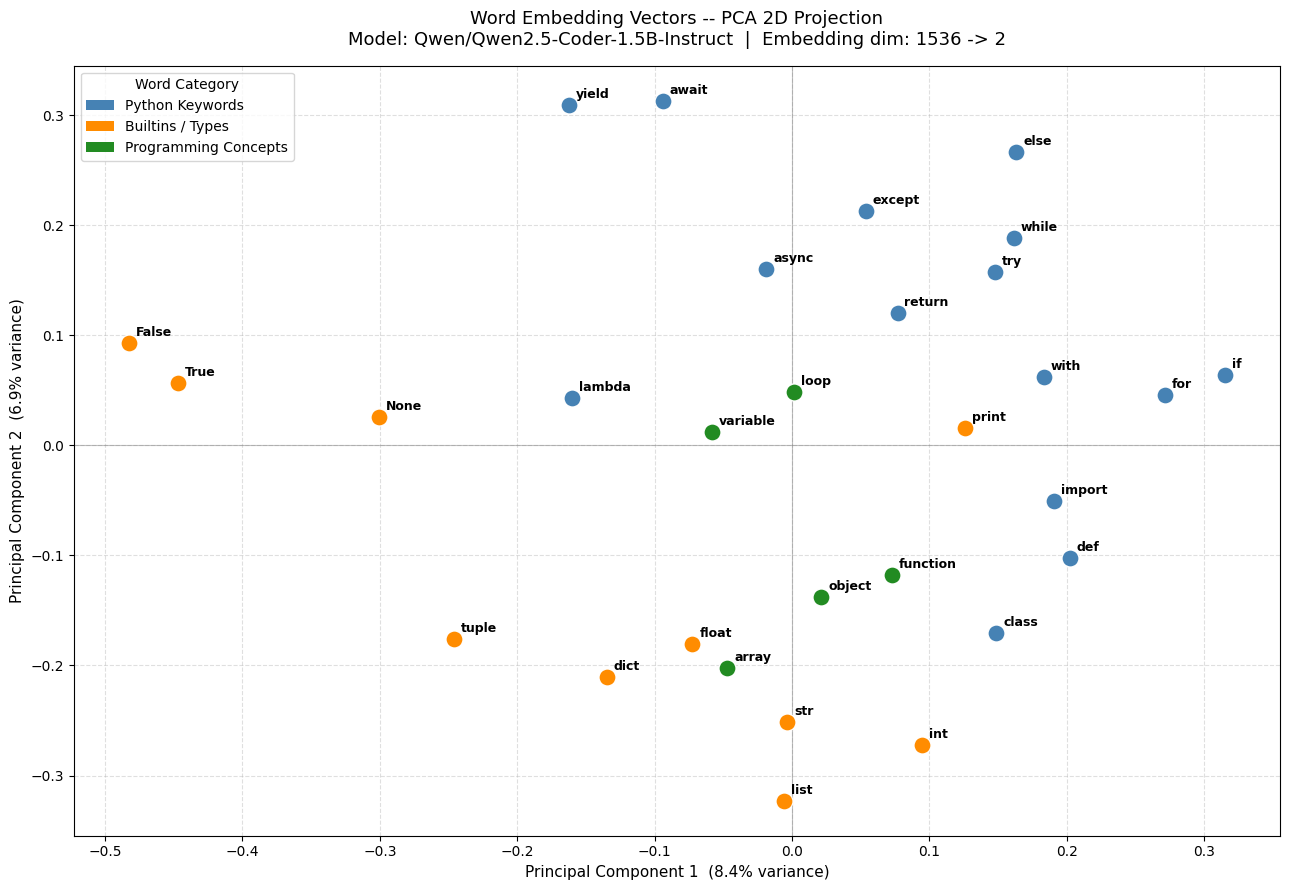


PCA plot saved to : ./qwen-coder-finetuned\pca_word_vectors.png


In [17]:
# Step 6b: Reduce high-dimensional embeddings to 2D using PCA
pca        = PCA(n_components=2, random_state=42)
vectors_2d = pca.fit_transform(word_vectors)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
print(f"PC1 variance explained : {var1:.2f}%")
print(f"PC2 variance explained : {var2:.2f}%")
print(f"Total explained        : {var1 + var2:.2f}%")

# Step 6c: Scatter plot with category-based color coding
fig, ax = plt.subplots(figsize=(13, 9))

for label, (x, y) in zip(word_labels, vectors_2d):
    cat   = word_to_cat.get(label, "Programming Concepts")
    color = category_colors[cat]
    ax.scatter(x, y, color=color, s=150, zorder=5,
               edgecolors="white", linewidths=0.9)
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="black",
    )

legend_handles = [
    mpatches.Patch(facecolor=color, label=cat)
    for cat, color in category_colors.items()
]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    fontsize=10,
    title="Word Category",
    title_fontsize=10,
)

title_line1 = "Word Embedding Vectors -- PCA 2D Projection"
title_line2 = f"Model: {MODEL_NAME}  |  Embedding dim: {word_vectors.shape[1]} -> 2"
ax.set_title(f"{title_line1}\n{title_line2}", fontsize=13, pad=15)
ax.set_xlabel(f"Principal Component 1  ({var1:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"Principal Component 2  ({var2:.1f}% variance)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, alpha=0.5)

plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
save_path = os.path.join(OUTPUT_DIR, "pca_word_vectors.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nPCA plot saved to : {save_path}")